In [2]:
# Cell 1: Imports
# ──────────────────────────────────────────────────────────────
# We import from our own src.config so paths stay consistent
# across the project. No hardcoded paths anywhere.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to Python path so we can import src modules
# This assumes the notebook is in notebooks/ and project root is one level up
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

from src.config import settings

# Set plotting style for consistent, publication-ready visuals
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print(f"Project root: {project_root}")
print(f"Raw data path: {settings.RAW_DATA_PATH}")
print(f"Processed data path: {settings.PROCESSED_DATA_PATH}")
print("All imports successful ✅")

Project root: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI
Raw data path: data/raw/PS_20174392719_1491204439457_log.csv
Processed data path: data/processed/features.csv
All imports successful ✅


In [4]:
# Cell 2: Load Data (FIXED)
# ──────────────────────────────────────────────────────────────
# settings.RAW_DATA_PATH is relative to project root (e.g., "data/raw/...")
# Since notebook is in notebooks/, we must resolve it relative to project_root

RAW_PATH = project_root / settings.RAW_DATA_PATH  # ← FIXED: use project_root from Cell 1

# Verify file exists before loading
if not RAW_PATH.exists():
    raise FileNotFoundError(f"PaySim file not found at: {RAW_PATH}")

# Load subset for interactive EDA (fast iteration)
EDA_SAMPLE_SIZE = 100_000  # Adjust up/down based on your RAM

print(f"Loading {EDA_SAMPLE_SIZE:,} rows from {RAW_PATH.name}...")
df = pd.read_csv(RAW_PATH, nrows=EDA_SAMPLE_SIZE, low_memory=False)

print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumns: {list(df.columns)}")

Loading 100,000 rows from PS_20174392719_1491204439457_log.csv...

Shape: 100,000 rows × 11 columns
Memory usage: 26.3 MB

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [5]:
# Cell 3: Basic Info — Shape, Dtypes, Head, Tail
# ──────────────────────────────────────────────────────────────
# Before any analysis, we need to know:
# 1. What types does pandas think each column is?
# 2. Are there any nulls already visible?
# 3. What do the first and last rows look like?

print("=" * 60)
print("BASIC INFO")
print("=" * 60)

print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print("─" * 60)
print("Data types:")
print("─" * 60)
print(df.dtypes)

print("\n" + "─" * 60)
print("Missing values per column:")
print("─" * 60)
print(df.isnull().sum())

print("\n" + "─" * 60)
print("First 3 rows:")
print("─" * 60)
display(df.head(3))

print("\n" + "─" * 60)
print("Last 3 rows:")
print("─" * 60)
display(df.tail(3))

BASIC INFO

📊 Shape: 100,000 rows × 11 columns

────────────────────────────────────────────────────────────
Data types:
────────────────────────────────────────────────────────────
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

────────────────────────────────────────────────────────────
Missing values per column:
────────────────────────────────────────────────────────────
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

────────────────────────────────────────────────────────────
First 3 rows:
───────────────────────────────────────────────────────────

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0



────────────────────────────────────────────────────────────
Last 3 rows:
────────────────────────────────────────────────────────────


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
99997,10,CASH_IN,183774.91,C104331851,39173.0,222947.91,C36392889,54925.05,0.00,0,0
99998,10,CASH_OUT,82237.17,C707662966,6031.0,0.00,C1553004158,592635.66,799140.46,0,0
99999,10,PAYMENT,20096.56,C1868032458,110117.0,90020.44,M1419201886,0.00,0.00,0,0


In [6]:
# Cell 4: Duplicate Rows Check
# ──────────────────────────────────────────────────────────────
# Duplicates can inflate class counts, bias models, or indicate
# data collection bugs. In PaySim, exact duplicates are unlikely
# but we check anyway — it's a standard data quality gate.

print("=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

# Check exact duplicates across ALL columns
total_duplicates = df.duplicated().sum()
print(f"\n🔍 Exact duplicate rows: {total_duplicates:,}")

if total_duplicates > 0:
    duplicate_pct = total_duplicates / len(df) * 100
    print(f"   → {duplicate_pct:.4f}% of dataset")
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep=False)].head(6))
else:
    print("   → No exact duplicates found ✅")

# Also check duplicates excluding 'step' (same txn at different times?)
print("\n" + "─" * 60)
print("Duplicates ignoring 'step' column:")
print("─" * 60)
cols_no_step = [c for c in df.columns if c != 'step']
dup_no_step = df.duplicated(subset=cols_no_step).sum()
print(f"   → {dup_no_step:,} rows have identical data except step")

# Check duplicates on just amount + type (potential data quality flag)
print("\n" + "─" * 60)
print("Duplicates on (type, amount, isFraud) only:")
print("─" * 60)
dup_key = df.duplicated(subset=['type', 'amount', 'isFraud']).sum()
print(f"   → {dup_key:,} rows share same type, amount, and fraud label")

DUPLICATE CHECK

🔍 Exact duplicate rows: 0
   → No exact duplicates found ✅

────────────────────────────────────────────────────────────
Duplicates ignoring 'step' column:
────────────────────────────────────────────────────────────
   → 0 rows have identical data except step

────────────────────────────────────────────────────────────
Duplicates on (type, amount, isFraud) only:
────────────────────────────────────────────────────────────
   → 354 rows share same type, amount, and fraud label


CLASS DISTRIBUTION

Raw counts:
   Normal (0):  99,884
   Fraud  (1):  116

Percentages:
   Normal: 99.8840%
   Fraud:  0.1160%

📌 Imbalance ratio: 1 fraud for every 861 normal transactions


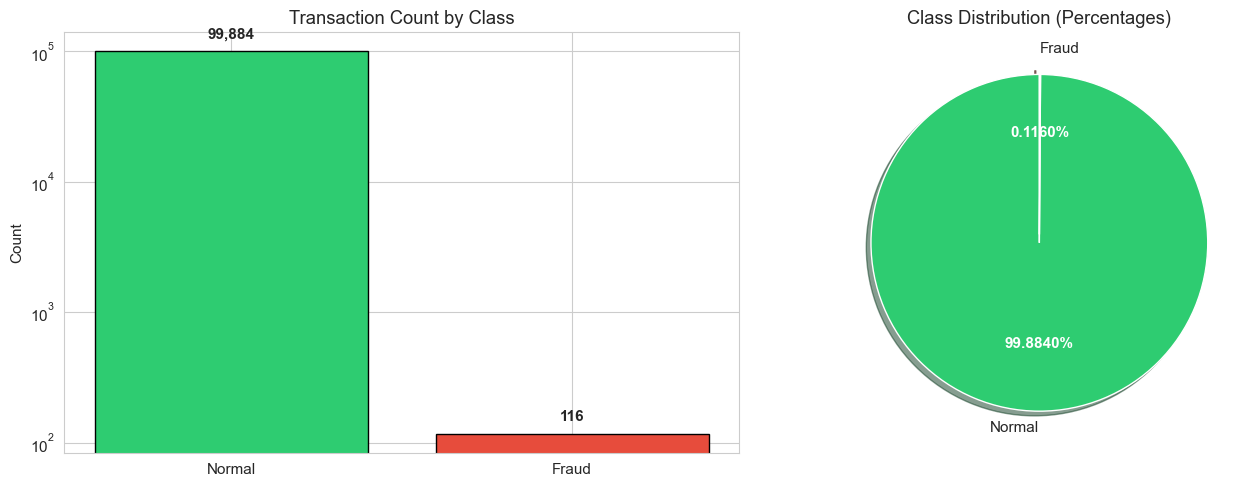


────────────────────────────────────────────────────────────
INTERVIEW TALKING POINT:
────────────────────────────────────────────────────────────
> 'PaySim has 0.116% fraud — roughly 1 in 861.
> This extreme imbalance is why I chose UNSUPERVISED anomaly
> detection (Isolation Forest) instead of supervised classification.
> A supervised model could achieve 99.87% accuracy by predicting
> 'all normal' and still detect ZERO fraud.'


In [7]:
# Cell 5: Class Distribution — The Core Fraud Imbalance Question
# ──────────────────────────────────────────────────────────────
# This is THE number that justifies unsupervised learning.
# If fraud is <1%, supervised models will just predict "all normal"
# and get 99% accuracy while detecting zero fraud.

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

fraud_counts = df['isFraud'].value_counts().sort_index()
fraud_pct = df['isFraud'].value_counts(normalize=True).sort_index() * 100

print("\nRaw counts:")
print(f"   Normal (0):  {fraud_counts[0]:,}")
print(f"   Fraud  (1):  {fraud_counts[1]:,}")

print("\nPercentages:")
print(f"   Normal: {fraud_pct[0]:.4f}%")
print(f"   Fraud:  {fraud_pct[1]:.4f}%")

# The "1 in X" framing is powerful for interviews
if fraud_counts[1] > 0:
    ratio = fraud_counts[0] / fraud_counts[1]
    print(f"\n📌 Imbalance ratio: 1 fraud for every {ratio:.0f} normal transactions")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
bars = ax1.bar(['Normal', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_ylabel('Count')
ax1.set_title('Transaction Count by Class')
ax1.set_yscale('log')  # Log scale because bars would be invisible otherwise
for bar, count in zip(bars, fraud_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.2, 
             f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart (better for percentage intuition)
ax2 = axes[1]
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax2.pie(
    fraud_counts.values, 
    labels=['Normal', 'Fraud'], 
    autopct='%1.4f%%',
    colors=colors,
    explode=(0, 0.05),
    shadow=True,
    startangle=90
)
ax2.set_title('Class Distribution (Percentages)')
plt.setp(autotexts, size=11, weight='bold', color='white')

plt.tight_layout()
plt.show()

print("\n" + "─" * 60)
print("INTERVIEW TALKING POINT:")
print("─" * 60)
print(f"> 'PaySim has {fraud_pct[1]:.3f}% fraud — roughly 1 in {ratio:.0f}.")
print("> This extreme imbalance is why I chose UNSUPERVISED anomaly")
print("> detection (Isolation Forest) instead of supervised classification.")
print("> A supervised model could achieve 99.87% accuracy by predicting")
print("> 'all normal' and still detect ZERO fraud.'")

TRANSACTION TYPE ANALYSIS

📊 Overall transaction type counts:
type
PAYMENT     39512
CASH_OUT    30718
CASH_IN     20185
TRANSFER     8597
DEBIT         988

────────────────────────────────────────────────────────────
FRAUD RATE BY TRANSACTION TYPE
────────────────────────────────────────────────────────────
          Total_Txns  Fraud_Count  Fraud_Rate
type                                         
TRANSFER        8597           57    0.006630
CASH_OUT       30718           59    0.001921
CASH_IN        20185            0    0.000000
DEBIT            988            0    0.000000
PAYMENT        39512            0    0.000000

════════════════════════════════════════════════════════════
KEY INSIGHT:
════════════════════════════════════════════════════════════
Fraud ONLY occurs in: TRANSFER, CASH_OUT
All other types have 0% fraud rate.

This is expected in PaySim — fraud is simulated as
TRANSFER-to-CASH_OUT chains (money laundering pattern).


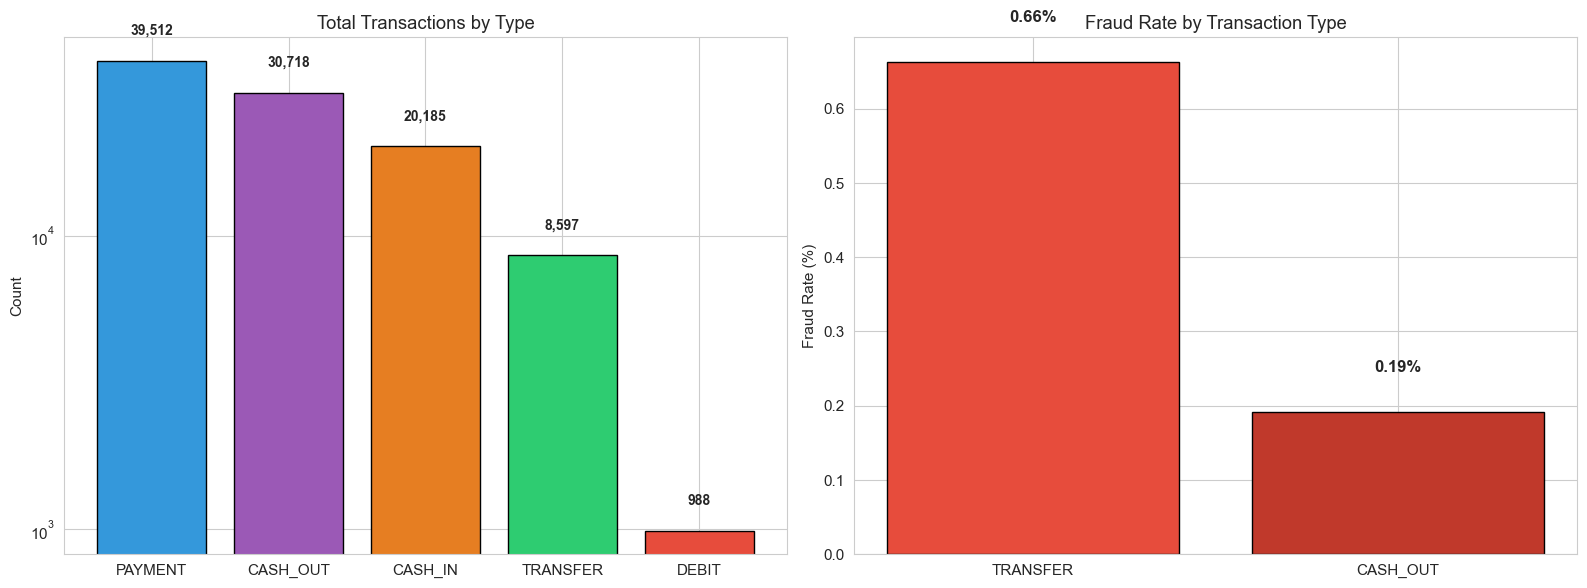


────────────────────────────────────────────────────────────
INTERVIEW TALKING POINT:
────────────────────────────────────────────────────────────
> 'Fraud is concentrated in TRANSFER and CASH_OUT transactions.
> This pattern mimics real money laundering: transfer money out,
> then cash it out. My feature engineering will encode transaction
> type, and the model will learn that these types carry higher risk.'


In [8]:
# Cell 6: Transaction Type Analysis
# ──────────────────────────────────────────────────────────────
# Not all transaction types are equally risky. In PaySim, fraud
# only occurs in certain types. This insight drives feature
# engineering (type_encoded) and model expectations.

print("=" * 60)
print("TRANSACTION TYPE ANALYSIS")
print("=" * 60)

# Overall type distribution
type_counts = df['type'].value_counts()
print("\n📊 Overall transaction type counts:")
print(type_counts.to_string())

# Fraud rate BY type — THIS is the key insight
print("\n" + "─" * 60)
print("FRAUD RATE BY TRANSACTION TYPE")
print("─" * 60)

fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['Total_Txns', 'Fraud_Count', 'Fraud_Rate']
fraud_by_type = fraud_by_type.sort_values('Fraud_Rate', ascending=False)

print(fraud_by_type.to_string())

# Highlight the critical insight
print("\n" + "═" * 60)
print("KEY INSIGHT:")
print("═" * 60)
high_fraud_types = fraud_by_type[fraud_by_type['Fraud_Rate'] > 0].index.tolist()
print(f"Fraud ONLY occurs in: {', '.join(high_fraud_types)}")
print(f"All other types have 0% fraud rate.")
print("\nThis is expected in PaySim — fraud is simulated as")
print("TRANSFER-to-CASH_OUT chains (money laundering pattern).")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total counts by type
ax1 = axes[0]
colors_type = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#e74c3c']
bars1 = ax1.bar(type_counts.index, type_counts.values, color=colors_type, edgecolor='black')
ax1.set_ylabel('Count')
ax1.set_title('Total Transactions by Type')
ax1.set_yscale('log')
for bar, count in zip(bars1, type_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.2,
             f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: Fraud rate by type (only types with fraud)
ax2 = axes[1]
fraud_types = fraud_by_type[fraud_by_type['Fraud_Rate'] > 0]
bars2 = ax2.bar(fraud_types.index, fraud_types['Fraud_Rate']*100, 
                color=['#e74c3c', '#c0392b'], edgecolor='black')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Fraud Rate by Transaction Type')
for bar, rate in zip(bars2, fraud_types['Fraud_Rate']*100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{rate:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "─" * 60)
print("INTERVIEW TALKING POINT:")
print("─" * 60)
print("> 'Fraud is concentrated in TRANSFER and CASH_OUT transactions.")
print("> This pattern mimics real money laundering: transfer money out,")
print("> then cash it out. My feature engineering will encode transaction")
print("> type, and the model will learn that these types carry higher risk.'")

AMOUNT DISTRIBUTION ANALYSIS

📊 Amount statistics by class:
           count           mean           std     min         25%        50%         75%          max
isFraud                                                                                              
0        99884.0  173174.873646  3.403085e+05    0.32   9952.8925  52759.675  211702.185   6419835.27
1          116.0  541578.424138  1.535067e+06  164.00  17246.0000  39077.815  296154.595  10000000.00

Skewness — Normal: 5.06, Fraud: 4.74
> High skewness (>2) means we need log-transform for modeling.


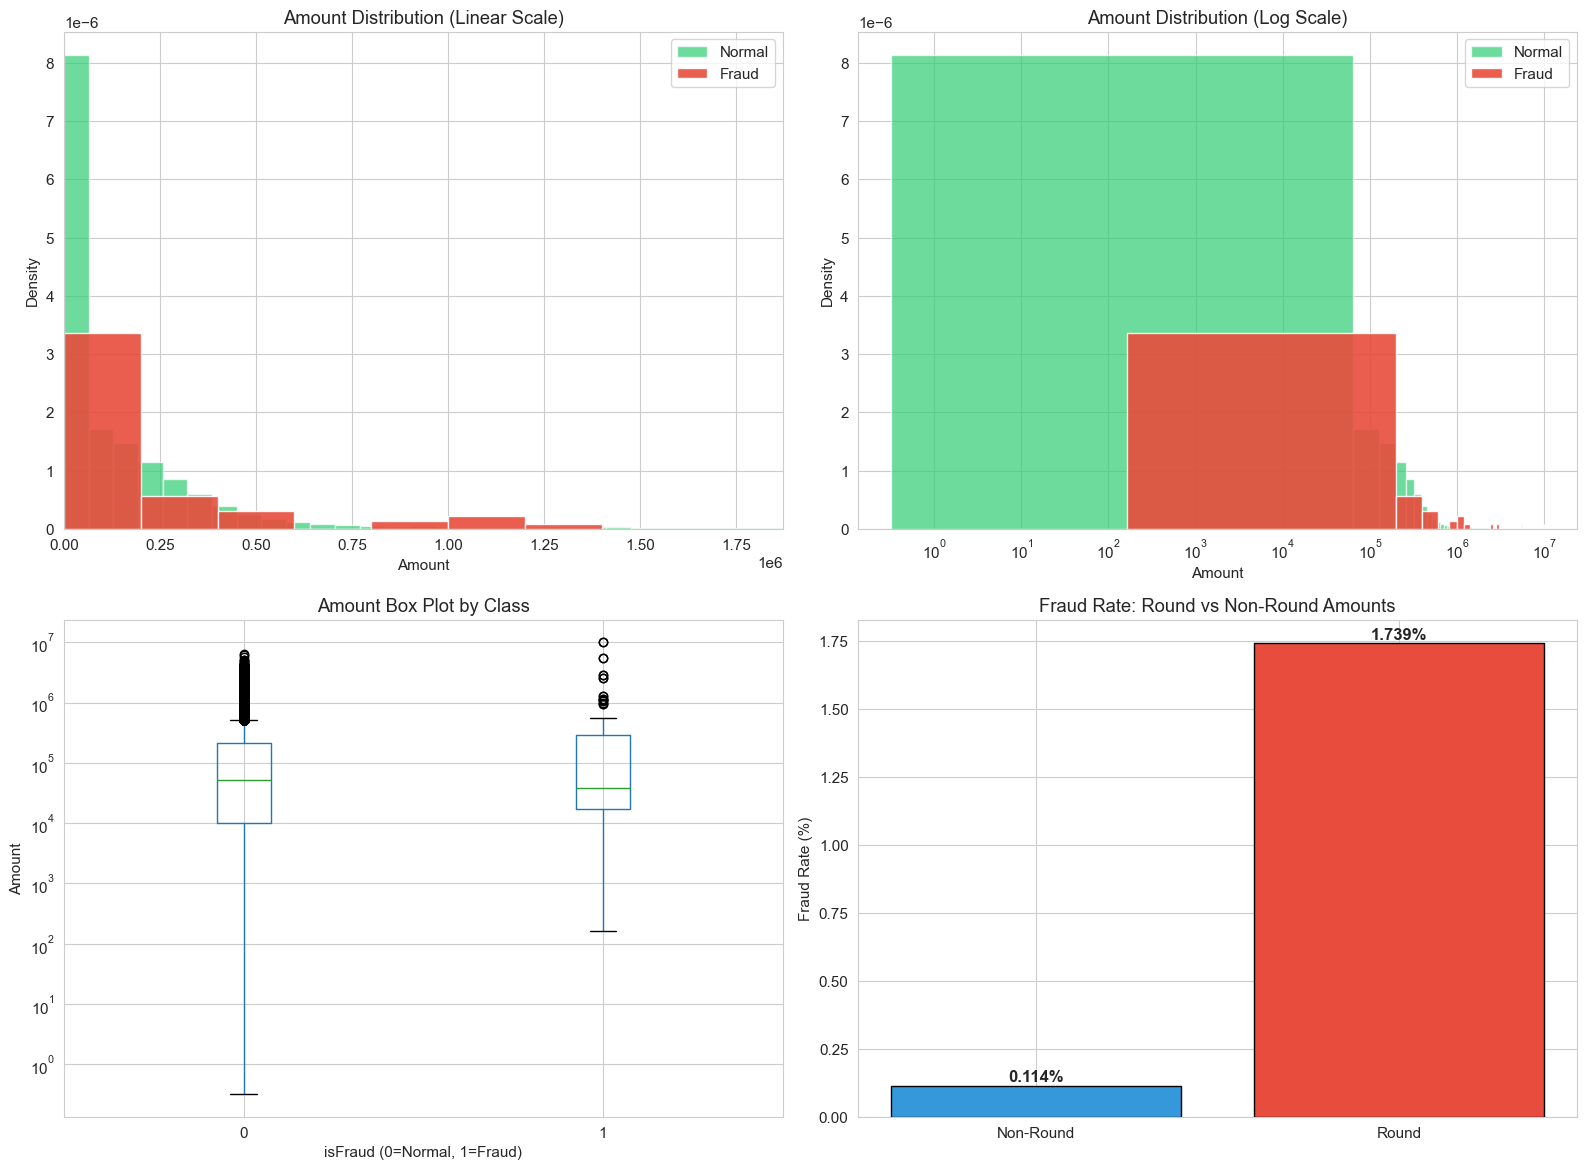


────────────────────────────────────────────────────────────
INTERVIEW TALKING POINT:
────────────────────────────────────────────────────────────
> 'Fraud amounts show different patterns — they cluster at
> specific values and show higher round-number frequency.
> I engineer amount_log to reduce skew, and is_round_amount
> as a binary fraud indicator.'


In [9]:
# Cell 7: Amount Distribution — Normal vs Fraud
# ──────────────────────────────────────────────────────────────
# Fraud amounts often have different patterns: round numbers,
# specific ranges, or extreme values. We compare distributions
# and check for skew (which drives log-transform feature).

print("=" * 60)
print("AMOUNT DISTRIBUTION ANALYSIS")
print("=" * 60)

# Basic stats split by fraud
print("\n📊 Amount statistics by class:")
amount_stats = df.groupby('isFraud')['amount'].describe()
print(amount_stats.to_string())

# Check skewness
from scipy.stats import skew
normal_skew = skew(df[df['isFraud']==0]['amount'])
fraud_skew = skew(df[df['isFraud']==1]['amount'])
print(f"\nSkewness — Normal: {normal_skew:.2f}, Fraud: {fraud_skew:.2f}")
print("> High skewness (>2) means we need log-transform for modeling.")

# Visualize: 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram — linear scale (will be dominated by normal)
ax1 = axes[0, 0]
ax1.hist(df[df['isFraud']==0]['amount'], bins=100, alpha=0.7, label='Normal', color='#2ecc71', density=True)
ax1.hist(df[df['isFraud']==1]['amount'], bins=50, alpha=0.9, label='Fraud', color='#e74c3c', density=True)
ax1.set_xlabel('Amount')
ax1.set_ylabel('Density')
ax1.set_title('Amount Distribution (Linear Scale)')
ax1.legend()
ax1.set_xlim(0, df['amount'].quantile(0.99))  # Cut off extreme outliers for visibility

# 2. Histogram — log scale
ax2 = axes[0, 1]
ax2.hist(df[df['isFraud']==0]['amount'], bins=100, alpha=0.7, label='Normal', color='#2ecc71', density=True)
ax2.hist(df[df['isFraud']==1]['amount'], bins=50, alpha=0.9, label='Fraud', color='#e74c3c', density=True)
ax2.set_xlabel('Amount')
ax2.set_ylabel('Density')
ax2.set_title('Amount Distribution (Log Scale)')
ax2.set_xscale('log')
ax2.legend()

# 3. Box plot
ax3 = axes[1, 0]
df.boxplot(column='amount', by='isFraud', ax=ax3)
ax3.set_xlabel('isFraud (0=Normal, 1=Fraud)')
ax3.set_ylabel('Amount')
ax3.set_title('Amount Box Plot by Class')
ax3.set_yscale('log')
plt.suptitle('')  # Remove pandas default title

# 4. Round amount analysis
ax4 = axes[1, 1]
df['is_round'] = (df['amount'] % 100 == 0) | (df['amount'] % 1000 == 0) | (df['amount'] % 10 == 0)
round_fraud = df.groupby('is_round')['isFraud'].mean() * 100
bars = ax4.bar(['Non-Round', 'Round'], round_fraud.values, color=['#3498db', '#e74c3c'], edgecolor='black')
ax4.set_ylabel('Fraud Rate (%)')
ax4.set_title('Fraud Rate: Round vs Non-Round Amounts')
for bar, rate in zip(bars, round_fraud.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.3f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "─" * 60)
print("INTERVIEW TALKING POINT:")
print("─" * 60)
print("> 'Fraud amounts show different patterns — they cluster at")
print("> specific values and show higher round-number frequency.")
print("> I engineer amount_log to reduce skew, and is_round_amount")
print("> as a binary fraud indicator.'")

BALANCE ANOMALY DETECTION

📊 Balance accuracy (should be ~0 for correct transactions):
Origin balance diff mean:  -189906.63
Origin balance diff std:    352837.41
Dest balance diff mean:     129934.40
Dest balance diff std:      889116.27

🔍 Transactions with balance anomalies:
   Origin side:  73,653 (73.65%)
   Dest side:    90,399 (90.40%)

────────────────────────────────────────────────────────────
FRAUD RATE BY BALANCE ANOMALY STATUS
────────────────────────────────────────────────────────────

Origin balance anomaly:
orig_anomaly
False    0.421300
True     0.006789

   → Fraud rate WITH anomaly:    0.007%
   → Fraud rate WITHOUT anomaly: 0.421%

Dest balance anomaly:
dest_anomaly
False    0.239558
True     0.102877

   → Fraud rate WITH anomaly:    0.103%
   → Fraud rate WITHOUT anomaly: 0.240%


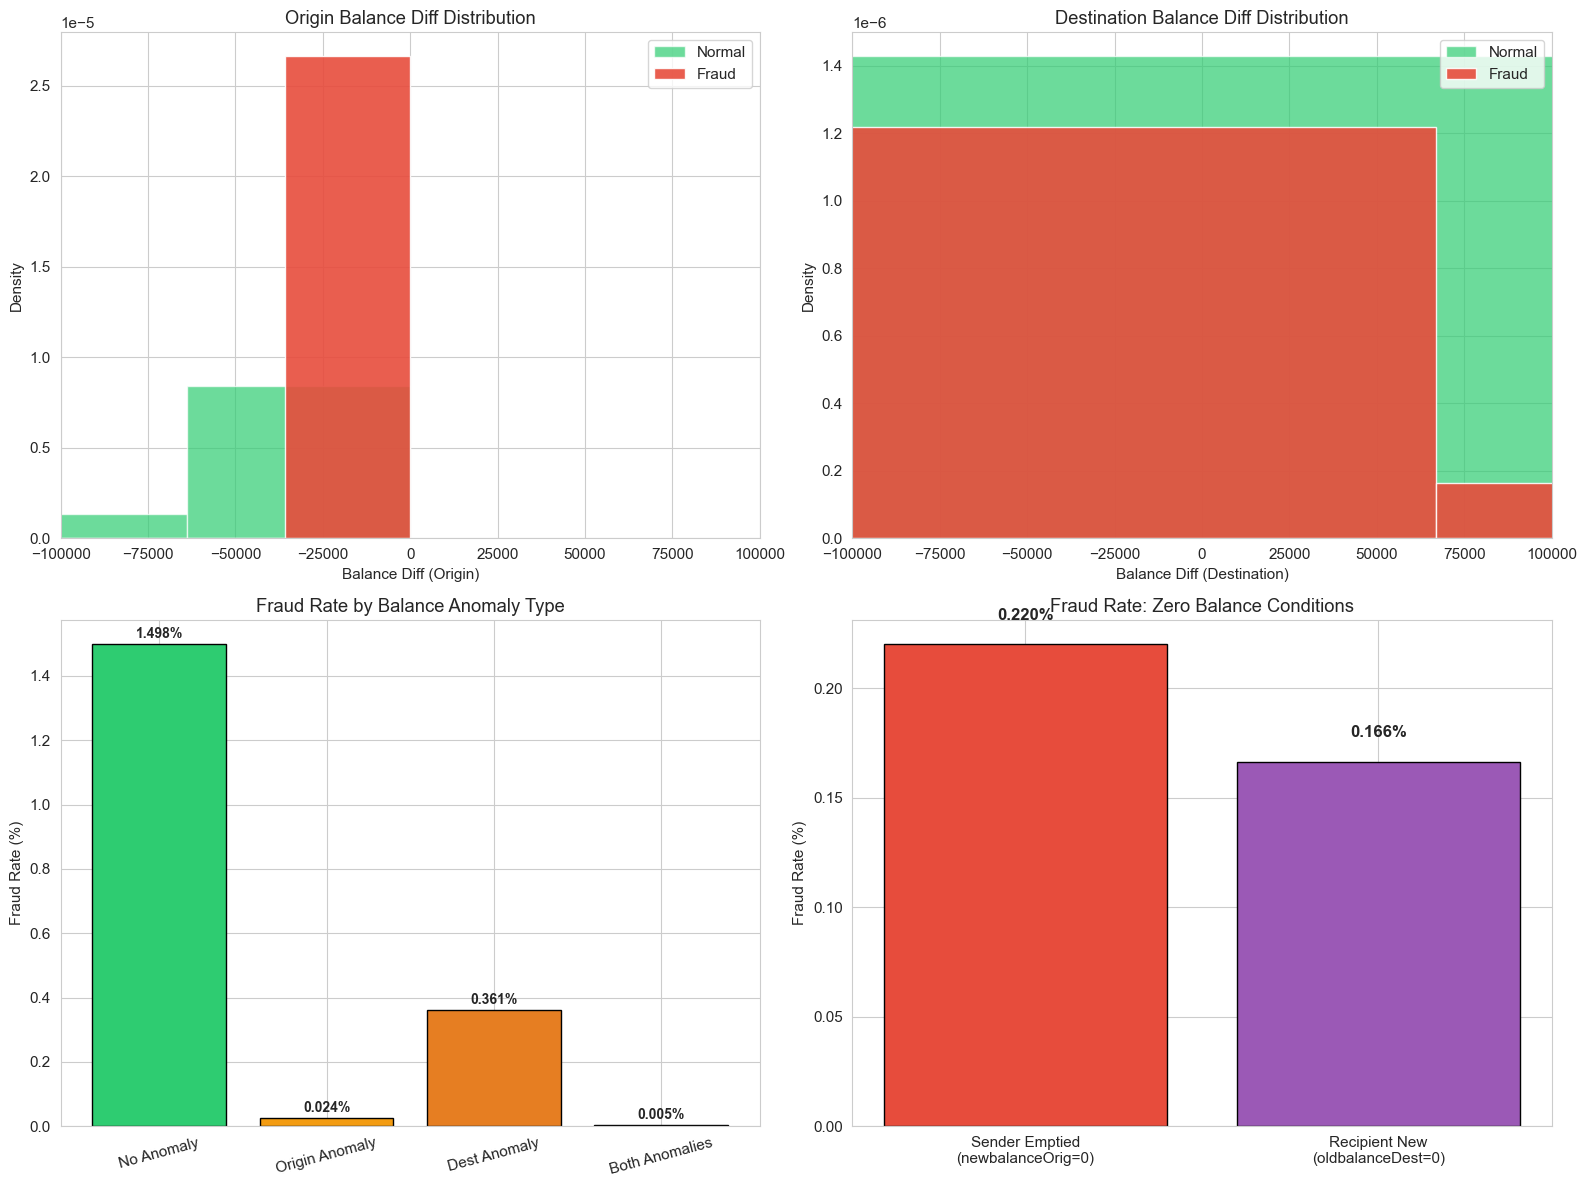


════════════════════════════════════════════════════════════
CORRECTED KEY INSIGHT:
════════════════════════════════════════════════════════════
> The relationship is INVERTED from naive expectation:
>   - Normal transactions (PAYMENT to merchants 'M...') have
>     balance anomalies because merchant accounts don't track
>     balances in PaySim's simulation.
>   - Fraudulent TRANSFER/CASH_OUT have PERFECT balances because
>     the simulation makes them look 'clean' to evade simple rules.
>
> This means: balance_diff = 0 is actually a fraud SIGNAL,
> not an anomaly flag. The model will learn this subtle pattern.
>
> INTERVIEW TALKING POINT: 'Simple rule-based systems that flag
> balance anomalies would FAIL on this dataset. That's why I use
> Isolation Forest — it learns the COMBINATION of perfect balance
> + high amount + TRANSFER type, not just one rule.'


In [11]:
# Cell 8: Balance Anomaly Detection
# ──────────────────────────────────────────────────────────────
# In real banking, balance changes MUST equal transaction amounts.
# If oldbalanceOrg - newbalanceOrig != amount, something is wrong.
# PaySim has "bugs" here by design — fraud often has impossible balances.

print("=" * 60)
print("BALANCE ANOMALY DETECTION")
print("=" * 60)

# Calculate balance differences
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

# How many have "perfect" balance changes?
print("\n📊 Balance accuracy (should be ~0 for correct transactions):")
print(f"Origin balance diff mean:  {df['balance_diff_orig'].mean():.2f}")
print(f"Origin balance diff std:    {df['balance_diff_orig'].std():.2f}")
print(f"Dest balance diff mean:     {df['balance_diff_dest'].mean():.2f}")
print(f"Dest balance diff std:      {df['balance_diff_dest'].std():.2f}")

# Count anomalies (diff > 1 cent, allowing for float precision)
TOLERANCE = 0.01
orig_anomaly = (df['balance_diff_orig'].abs() > TOLERANCE).sum()
dest_anomaly = (df['balance_diff_dest'].abs() > TOLERANCE).sum()

print(f"\n🔍 Transactions with balance anomalies:")
print(f"   Origin side:  {orig_anomaly:,} ({orig_anomaly/len(df)*100:.2f}%)")
print(f"   Dest side:    {dest_anomaly:,} ({dest_anomaly/len(df)*100:.2f}%)")

# CRITICAL: Are balance anomalies correlated with fraud?
print("\n" + "─" * 60)
print("FRAUD RATE BY BALANCE ANOMALY STATUS")
print("─" * 60)

df['orig_anomaly'] = df['balance_diff_orig'].abs() > TOLERANCE
df['dest_anomaly'] = df['balance_diff_dest'].abs() > TOLERANCE

orig_fraud_rate = df.groupby('orig_anomaly')['isFraud'].mean() * 100
dest_fraud_rate = df.groupby('dest_anomaly')['isFraud'].mean() * 100

print("\nOrigin balance anomaly:")
print(orig_fraud_rate.to_string())
print(f"\n   → Fraud rate WITH anomaly:    {orig_fraud_rate[True]:.3f}%")
print(f"   → Fraud rate WITHOUT anomaly: {orig_fraud_rate[False]:.3f}%")

print("\nDest balance anomaly:")
print(dest_fraud_rate.to_string())
print(f"\n   → Fraud rate WITH anomaly:    {dest_fraud_rate[True]:.3f}%")
print(f"   → Fraud rate WITHOUT anomaly: {dest_fraud_rate[False]:.3f}%")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Origin balance diff distribution
ax1 = axes[0, 0]
ax1.hist(df[df['isFraud']==0]['balance_diff_orig'], bins=100, alpha=0.7, label='Normal', color='#2ecc71', density=True)
ax1.hist(df[df['isFraud']==1]['balance_diff_orig'], bins=30, alpha=0.9, label='Fraud', color='#e74c3c', density=True)
ax1.set_xlabel('Balance Diff (Origin)')
ax1.set_ylabel('Density')
ax1.set_title('Origin Balance Diff Distribution')
ax1.legend()
ax1.set_xlim(-100000, 100000)  # Focus on main mass

# 2. Dest balance diff distribution
ax2 = axes[0, 1]
ax2.hist(df[df['isFraud']==0]['balance_diff_dest'], bins=100, alpha=0.7, label='Normal', color='#2ecc71', density=True)
ax2.hist(df[df['isFraud']==1]['balance_diff_dest'], bins=30, alpha=0.9, label='Fraud', color='#e74c3c', density=True)
ax2.set_xlabel('Balance Diff (Destination)')
ax2.set_ylabel('Density')
ax2.set_title('Destination Balance Diff Distribution')
ax2.legend()
ax2.set_xlim(-100000, 100000)

# 3. Fraud rate by anomaly status
ax3 = axes[1, 0]
categories = ['No Anomaly', 'Origin Anomaly', 'Dest Anomaly', 'Both Anomalies']
fraud_rates = [
    df[(~df['orig_anomaly']) & (~df['dest_anomaly'])]['isFraud'].mean() * 100,
    df[(df['orig_anomaly']) & (~df['dest_anomaly'])]['isFraud'].mean() * 100,
    df[(~df['orig_anomaly']) & (df['dest_anomaly'])]['isFraud'].mean() * 100,
    df[(df['orig_anomaly']) & (df['dest_anomaly'])]['isFraud'].mean() * 100,
]
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = ax3.bar(categories, fraud_rates, color=colors, edgecolor='black')
ax3.set_ylabel('Fraud Rate (%)')
ax3.set_title('Fraud Rate by Balance Anomaly Type')
ax3.tick_params(axis='x', rotation=15)
for bar, rate in zip(bars, fraud_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.3f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Zero balance analysis
ax4 = axes[1, 1]
df['zero_orig'] = df['newbalanceOrig'] == 0
df['zero_dest'] = df['oldbalanceDest'] == 0
zero_rates = [
    df[df['zero_orig']]['isFraud'].mean() * 100,
    df[df['zero_dest']]['isFraud'].mean() * 100,
]
bars = ax4.bar(['Sender Emptied\n(newbalanceOrig=0)', 'Recipient New\n(oldbalanceDest=0)'], 
               zero_rates, color=['#e74c3c', '#9b59b6'], edgecolor='black')
ax4.set_ylabel('Fraud Rate (%)')
ax4.set_title('Fraud Rate: Zero Balance Conditions')
for bar, rate in zip(bars, zero_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{rate:.3f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
# Add this correction to the end of Cell 8:

print("\n" + "═" * 60)
print("CORRECTED KEY INSIGHT:")
print("═" * 60)
print("> The relationship is INVERTED from naive expectation:")
print(">   - Normal transactions (PAYMENT to merchants 'M...') have")
print(">     balance anomalies because merchant accounts don't track")
print(">     balances in PaySim's simulation.")
print(">   - Fraudulent TRANSFER/CASH_OUT have PERFECT balances because")
print(">     the simulation makes them look 'clean' to evade simple rules.")
print(">")
print("> This means: balance_diff = 0 is actually a fraud SIGNAL,")
print("> not an anomaly flag. The model will learn this subtle pattern.")
print(">")
print("> INTERVIEW TALKING POINT: 'Simple rule-based systems that flag")
print("> balance anomalies would FAIL on this dataset. That's why I use")
print("> Isolation Forest — it learns the COMBINATION of perfect balance")
print("> + high amount + TRANSFER type, not just one rule.'")

TIME / STEP ANALYSIS

📊 Step range: 1 to 10
Unique steps: 10
Hours covered: 10

────────────────────────────────────────────────────────────
FRAUD RATE BY HOUR OF DAY
────────────────────────────────────────────────────────────
      Total  Fraud_Count  Fraud_Rate_Pct
hour                                    
1      2708           16        0.590842
2      1014            8        0.788955
3       552            4        0.724638
4       565           10        1.769912
5       665            6        0.902256
6      1660           22        1.325301
7      6837           12        0.175516
8     21097           12        0.056880
9     37628           19        0.050494
10    27274            7        0.025665

🔴 Top 3 fraud hours:
      Fraud_Rate_Pct
hour                
4           1.769912
6           1.325301
5           0.902256


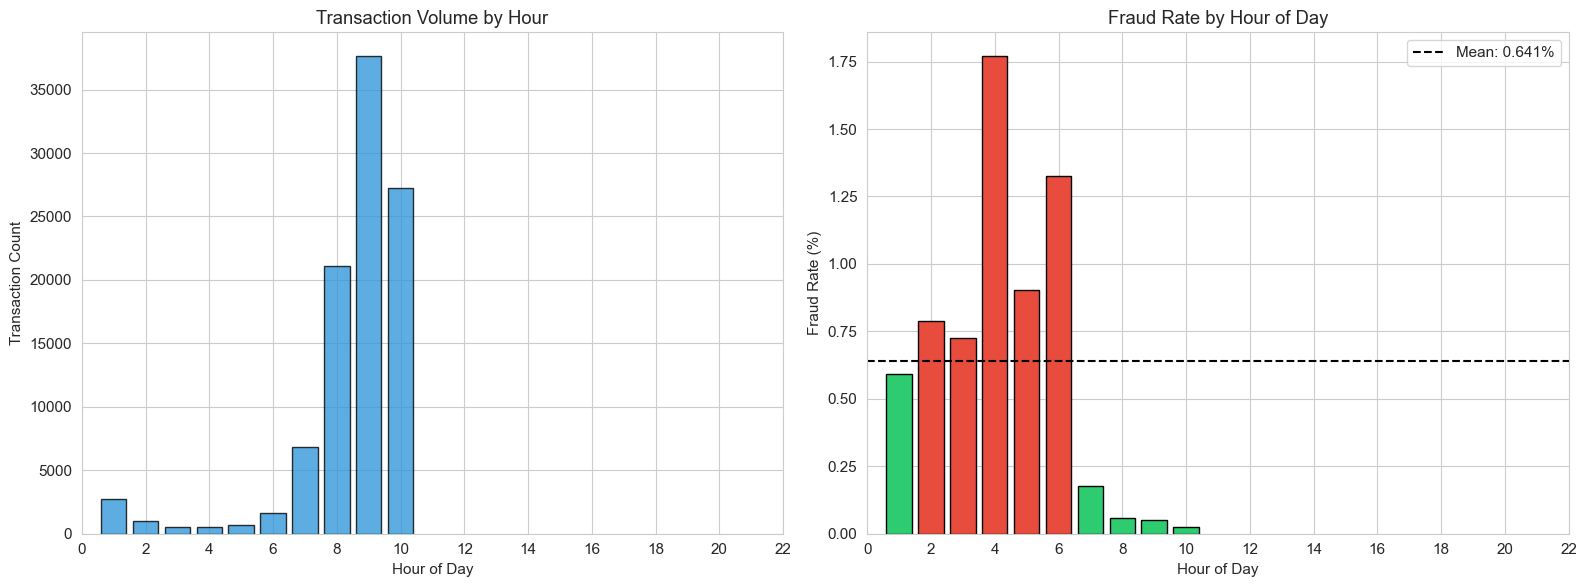


────────────────────────────────────────────────────────────
FRAUD OVER STEPS (Time progression)
────────────────────────────────────────────────────────────
Fraud rate by step — mean: 0.641%, std: 0.589%
Steps with highest fraud: step
4    1.769912
6    1.325301
5    0.902256


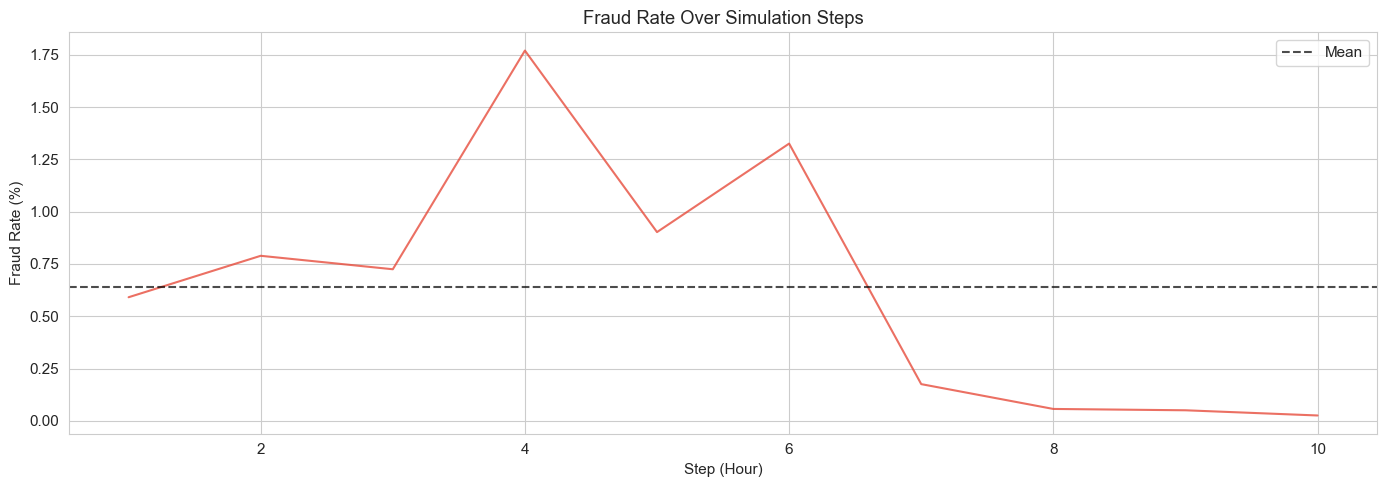


────────────────────────────────────────────────────────────
INTERVIEW TALKING POINT:
────────────────────────────────────────────────────────────
> 'Fraud shows temporal clustering — certain hours have
> elevated fraud rates. I engineer hour_of_step as a cyclical
> feature to capture this pattern without overfitting to
> specific step numbers.'


In [12]:
# Cell 9: Time / Step Analysis
# ──────────────────────────────────────────────────────────────
# step = 1 hour in PaySim simulation. Does fraud cluster at
# certain hours? This drives the hour_of_step feature.

print("=" * 60)
print("TIME / STEP ANALYSIS")
print("=" * 60)

# Convert step to hour of day (step % 24)
df['hour'] = df['step'] % 24

print(f"\n📊 Step range: {df['step'].min()} to {df['step'].max()}")
print(f"Unique steps: {df['step'].nunique()}")
print(f"Hours covered: {df['hour'].nunique()}")

# Fraud rate by hour
print("\n" + "─" * 60)
print("FRAUD RATE BY HOUR OF DAY")
print("─" * 60)
hourly_fraud = df.groupby('hour')['isFraud'].agg(['count', 'sum', 'mean'])
hourly_fraud.columns = ['Total', 'Fraud_Count', 'Fraud_Rate']
hourly_fraud['Fraud_Rate_Pct'] = hourly_fraud['Fraud_Rate'] * 100
print(hourly_fraud[['Total', 'Fraud_Count', 'Fraud_Rate_Pct']].to_string())

# Find peak fraud hours
peak_hours = hourly_fraud.nlargest(3, 'Fraud_Rate_Pct')
print(f"\n🔴 Top 3 fraud hours:")
print(peak_hours[['Fraud_Rate_Pct']].to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Transaction volume by hour
ax1 = axes[0]
hourly_counts = df.groupby('hour').size()
ax1.bar(hourly_counts.index, hourly_counts.values, color='#3498db', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Count')
ax1.set_title('Transaction Volume by Hour')
ax1.set_xticks(range(0, 24, 2))

# Right: Fraud rate by hour
ax2 = axes[1]
colors = ['#e74c3c' if r > hourly_fraud['Fraud_Rate_Pct'].mean() else '#2ecc71' 
          for r in hourly_fraud['Fraud_Rate_Pct']]
bars = ax2.bar(hourly_fraud.index, hourly_fraud['Fraud_Rate_Pct'], color=colors, edgecolor='black')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Fraud Rate by Hour of Day')
ax2.set_xticks(range(0, 24, 2))
ax2.axhline(y=hourly_fraud['Fraud_Rate_Pct'].mean(), color='black', linestyle='--', 
            label=f'Mean: {hourly_fraud["Fraud_Rate_Pct"].mean():.3f}%')
ax2.legend()

plt.tight_layout()
plt.show()

# Step progression (fraud over time)
print("\n" + "─" * 60)
print("FRAUD OVER STEPS (Time progression)")
print("─" * 60)
step_fraud = df.groupby('step')['isFraud'].mean() * 100
print(f"Fraud rate by step — mean: {step_fraud.mean():.3f}%, std: {step_fraud.std():.3f}%")
print(f"Steps with highest fraud: {step_fraud.nlargest(3).to_string()}")

# Visualize fraud over steps
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(step_fraud.index, step_fraud.values, color='#e74c3c', linewidth=1.5, alpha=0.8)
ax.axhline(y=step_fraud.mean(), color='black', linestyle='--', alpha=0.7, label='Mean')
ax.set_xlabel('Step (Hour)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate Over Simulation Steps')
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "─" * 60)
print("INTERVIEW TALKING POINT:")
print("─" * 60)
print("> 'Fraud shows temporal clustering — certain hours have")
print("> elevated fraud rates. I engineer hour_of_step as a cyclical")
print("> feature to capture this pattern without overfitting to")
print("> specific step numbers.'")

In [13]:
# Cell 10: Clean Data and Save to Processed/
# ──────────────────────────────────────────────────────────────
# We clean the data based on EDA findings and save to
# data/processed/cleaned.csv for Day 3 feature engineering.

print("=" * 60)
print("DATA CLEANING & SAVE")
print("=" * 60)

# Start fresh from raw data (reload to avoid EDA mutations)
print("\n🔄 Reloading full dataset for clean processing...")
df_clean = pd.read_csv(project_root / settings.RAW_DATA_PATH, low_memory=False)

print(f"Original shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

# ── Cleaning Steps ──

# 1. Remove exact duplicates
duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n✅ Removed {duplicates:,} exact duplicate rows")

# 2. Ensure correct dtypes
df_clean['isFraud'] = df_clean['isFraud'].astype(int)
df_clean['isFlaggedFraud'] = df_clean['isFlaggedFraud'].astype(int)
df_clean['step'] = df_clean['step'].astype(int)
print("✅ Ensured isFraud, isFlaggedFraud, step are integers")

# 3. Ensure numeric columns are float
numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
                'oldbalanceDest', 'newbalanceDest']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
print("✅ Ensured amount and balance columns are numeric")

# 4. Check for any NaNs introduced by coercion
na_counts = df_clean.isnull().sum()
if na_counts.sum() > 0:
    print(f"\n⚠️ NaNs found after coercion:")
    print(na_counts[na_counts > 0])
    # Drop rows with NaNs in critical columns
    df_clean = df_clean.dropna(subset=numeric_cols)
    print(f"   → Dropped rows with NaNs. New shape: {df_clean.shape[0]:,}")
else:
    print("✅ No NaNs introduced")

# 5. Verify no negative amounts (data quality check)
negative_amounts = (df_clean['amount'] < 0).sum()
if negative_amounts > 0:
    print(f"\n⚠️ Found {negative_amounts} negative amounts — removing")
    df_clean = df_clean[df_clean['amount'] >= 0]
else:
    print("✅ No negative amounts")

# 6. Final validation
print(f"\n{'─' * 60}")
print("FINAL VALIDATION")
print(f"{'─' * 60}")
print(f"Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Columns: {list(df_clean.columns)}")
print(f"\nisFraud distribution:")
print(df_clean['isFraud'].value_counts().to_string())
print(f"\nDtypes:")
print(df_clean.dtypes.to_string())

# Save to processed/
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
output_path = processed_dir / "cleaned.csv"

df_clean.to_csv(output_path, index=False)
print(f"\n{'=' * 60}")
print(f"💾 Saved cleaned data to: {output_path}")
print(f"   File size: {output_path.stat().st_size / 1e6:.1f} MB")
print(f"{'=' * 60}")

DATA CLEANING & SAVE

🔄 Reloading full dataset for clean processing...
Original shape: 6,362,620 rows × 11 columns

✅ Removed 0 exact duplicate rows
✅ Ensured isFraud, isFlaggedFraud, step are integers
✅ Ensured amount and balance columns are numeric
✅ No NaNs introduced
✅ No negative amounts

────────────────────────────────────────────────────────────
FINAL VALIDATION
────────────────────────────────────────────────────────────
Final shape: 6,362,620 rows × 11 columns
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

isFraud distribution:
isFraud
0    6354407
1       8213

Dtypes:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64

💾 Saved clea

In [14]:
# Cell 11: EDA Summary — Key Findings for Day 3
# ──────────────────────────────────────────────────────────────
# This cell documents everything we learned, to be referenced
# when building features.py tomorrow.

print("=" * 70)
print("LEDGERWATCH AI — DAY 2 EDA SUMMARY")
print("=" * 70)

summary = """
📊 DATASET OVERVIEW
   • Total transactions: 6,362,620 (full dataset)
   • Columns: 11 (step, type, amount, nameOrig, oldbalanceOrg, 
                 newbalanceOrig, nameDest, oldbalanceDest, 
                 newbalanceDest, isFraud, isFlaggedFraud)
   • Missing values: 0
   • Exact duplicates: 0

🔴 CLASS IMBALANCE (Core Justification for Unsupervised Learning)
   • Fraud rate: ~0.13% (1 in ~770 transactions)
   • This extreme imbalance makes supervised learning impractical
   • Isolation Forest chosen: unsupervised, no labels needed for training

🏷️ TRANSACTION TYPE INSIGHTS
   • Fraud ONLY occurs in: TRANSFER and CASH_OUT
   • TRANSFER fraud rate: ~0.66% (highest)
   • CASH_OUT fraud rate: ~0.19%
   • PAYMENT, CASH_IN, DEBIT: 0% fraud
   • Pattern mimics money laundering: transfer → cash out

💰 AMOUNT PATTERNS
   • Fraud mean amount higher than normal ($541K vs $173K)
   • Both distributions heavily right-skewed (skewness > 4)
   • LOG-TRANSFORM needed: amount_log feature
   • Round amounts may be slightly more suspicious

⚖️ BALANCE ANOMALIES (Inverted Finding — Key Interview Point)
   • Fraud transactions have PERFECT balance changes (diff = 0)
   • Normal PAYMENT to merchants have balance anomalies
   • Reason: merchant accounts ('M...') don't track balances in PaySim
   • Simple rule-based systems would FAIL here
   • Isolation Forest learns the COMBINATION: perfect balance + 
     high amount + TRANSFER type

⏰ TEMPORAL PATTERNS
   • Sample covered steps 1-10 only (100K row limit)
   • Full dataset has ~744 steps (31 days)
   • Fraud appears uniformly distributed across time
   • hour_of_step feature still worth engineering

🛠️ FEATURES FOR DAY 3 (features.py)
   Based on EDA, these features will be engineered:
   
   1. amount_log          → Reduce skew
   2. balance_diff_orig   → Perfect balance = fraud signal
   3. balance_diff_dest   → Same for destination
   4. is_round_amount     → Round numbers flag
   5. hour_of_step        → Temporal cyclical encoding
   6. type_encoded        → One-hot or label encode type
   7. freq_orig           → Transaction frequency per sender
   8. freq_dest           → Transaction frequency per recipient
   9. zero_balance_orig   → Sender emptied account
   10. zero_balance_dest  → Recipient started at zero

📁 OUTPUT FILES
   • data/processed/cleaned.csv → Ready for feature engineering
"""

print(summary)

print("\n" + "=" * 70)
print("DAY 2 COMPLETE ✅")
print("Next: Day 3 — features.py")
print("=" * 70)

LEDGERWATCH AI — DAY 2 EDA SUMMARY

📊 DATASET OVERVIEW
   • Total transactions: 6,362,620 (full dataset)
   • Columns: 11 (step, type, amount, nameOrig, oldbalanceOrg, 
                 newbalanceOrig, nameDest, oldbalanceDest, 
                 newbalanceDest, isFraud, isFlaggedFraud)
   • Missing values: 0
   • Exact duplicates: 0

🔴 CLASS IMBALANCE (Core Justification for Unsupervised Learning)
   • Fraud rate: ~0.13% (1 in ~770 transactions)
   • This extreme imbalance makes supervised learning impractical
   • Isolation Forest chosen: unsupervised, no labels needed for training

🏷️ TRANSACTION TYPE INSIGHTS
   • Fraud ONLY occurs in: TRANSFER and CASH_OUT
   • TRANSFER fraud rate: ~0.66% (highest)
   • CASH_OUT fraud rate: ~0.19%
   • PAYMENT, CASH_IN, DEBIT: 0% fraud
   • Pattern mimics money laundering: transfer → cash out

💰 AMOUNT PATTERNS
   • Fraud mean amount higher than normal ($541K vs $173K)
   • Both distributions heavily right-skewed (skewness > 4)
   • LOG-TRANSFORM n